### Week 11 Examples: Pandas: Joining DataFrames, Grouping ###



In [78]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set the option to display all columns
pd.set_option('display.max_columns', None)
# Set the option to display more width (scroll to the right)
pd.set_option('display.width', 1000)


Joining DataFrames

In [84]:
# load data files:
df_components = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/refs/heads/main/data/components.tsv", sep='\t')
df_orders = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/refs/heads/main/data/orders.tsv", sep='\t')

# print("COMPONENTS")
# print(df_components)
# print("ORDERS")
# print(df_orders)

# # join (merge) these two dataframes together
df_component_orders = df_components.merge(df_orders, on="device")
df_component_orders['order_qty'] = df_component_orders['component_quantity'] * df_component_orders['device_quantity']
print(df_component_orders)
# # what is total number of stuffs do we need to fulfill the orders?
print(df_component_orders.groupby('component')['order_qty'].sum())



   device  component  component_quantity  device_quantity  order_qty
0  gadget       gear                  13                3         39
1  gadget     spring                  17                3         51
2   gizmo   sprocket                   7                2         14
3   gizmo     oilcan                   2                2          4
4  widget   sprocket                  11                5         55
5  widget     spring                   4                5         20
6  widget       bolt                   5                5         25
7  widget  sandpaper                   3                5         15
component
bolt         25
gear         39
oilcan        4
sandpaper    15
spring       71
sprocket     69
Name: order_qty, dtype: int64


Load Chicago Marathon Data

In [43]:

# load data file:
df_marathon = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/refs/heads/main/data/2025_chicago_results.csv", index_col="BIB")

# print('df_marathon.columns:', df_marathon.columns)


df_marathon.columns: Index(['name_(ctz)', 'short', 'gender', 'city,_state', 'bib', 'division', 'start_time', 'place_overall', 'place_gender', 'place_division', 'last_split', '05k', '10k', '15k', '20k', 'half', '25k', '30k', 'mile_20', 'mile_21', '35k', 'mile_22', 'mile_23', 'mile_24', '40k', 'mile_25', 'mile_25.2', 'finish', 'half_2', 'finish_tod', '05k_hours', '10k_hours', '15k_hours', '20k_hours', 'half_hours', '25k_hours', '30k_hours', 'mile_20_hours', 'mile_21_hours', '35k_hours', 'mile_22_hours', 'mile_23_hours', 'mile_24_hours', '40k_hours', 'mile_25_hours', 'mile_25.2_hours', 'finish_hours', 'half_2_hours', '05k_pace', '10k_pace', '15k_pace', '20k_pace', '25k_pace', '30k_pace', '35k_pace', '40k_pace', 'splits_mean', 'splits_std', 'start_place', 'finish_place', 'num_passed'], dtype='str')


Exploratory data analysis:
- explore some columns/values
- use groups of columns together

count    54269.000000
mean         4.366082
std          1.049449
min          2.039722
25%          3.564167
50%          4.217222
75%          5.019444
max         10.039167
Name: finish_hours, dtype: float64


Text(0, 0.5, 'count')

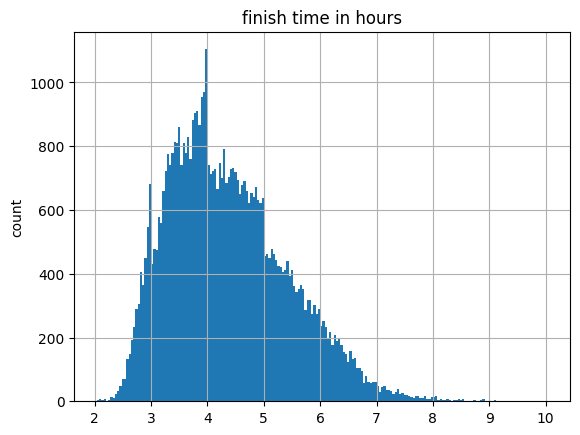

In [5]:
columns = ['name_(ctz)', 'gender', 'division', 'place_overall', 'finish']
time_columns = ['05k_hours', '10k_hours', '15k_hours', '20k_hours',
       'half_hours', '25k_hours', '30k_hours', 'mile_20_hours',
       'mile_21_hours', '35k_hours', 'mile_22_hours', 'mile_23_hours',
       'mile_24_hours', '40k_hours', 'mile_25_hours', 'mile_25.2_hours',
       'finish_hours', 'half_2_hours']
pace_columns = ['05k_pace', '10k_pace', '15k_pace',
       '20k_pace', '25k_pace', '30k_pace', '35k_pace', '40k_pace']

# print(df_marathon[columns])
# print(df_marathon[columns + pace_columns])

print(df_marathon['finish_hours'].describe())
df_marathon['finish_hours'].hist(bins=200)
plt.title('finish time in hours')
plt.ylabel('count')




Grouping data by gender

                 count      mean       std       min       25%       50%       75%        max
gender                                                                                       
Man            29530.0  4.111847  1.003142  2.039722  3.347222  3.930694  4.730417  10.039167
Non-binary       143.0  4.584396  1.199813  2.475278  3.543750  4.502500  5.525972   7.429722
Not specified     63.0  4.521671  1.085954  2.610556  3.796944  4.364722  5.022361   8.832778
Woman          24533.0  4.670430  1.021252  2.249167  3.890000  4.548889  5.332778   9.091944


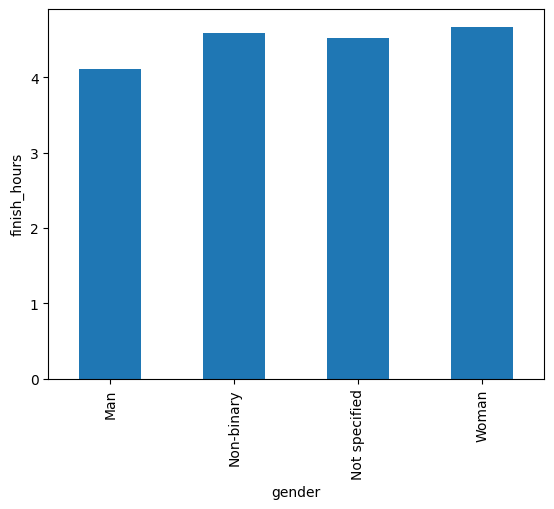

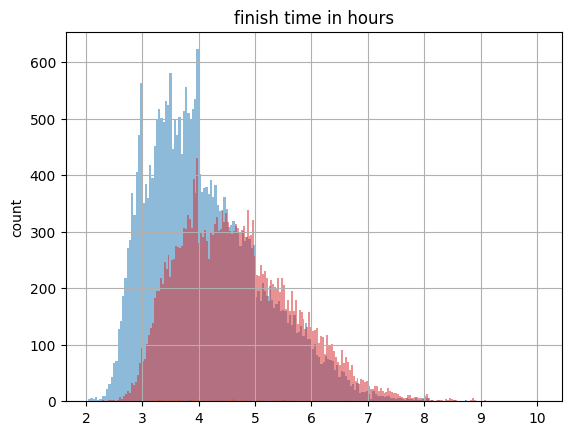

                05k_pace   10k_pace   15k_pace   20k_pace   25k_pace   30k_pace   35k_pace   40k_pace
gender                                                                                               
Man             8.787660   8.860314   8.687176   8.919877   9.228320   9.670675  10.093847  10.713570
Non-binary      9.650199   9.906422   9.650989   9.979365  10.522115  10.753887  11.177613  11.853369
Not specified   9.585509   9.760881   9.645929   9.597744   9.986074  10.593826  10.949705  11.497485
Woman          10.018191  10.230850  10.003665  10.308564  10.647849  10.987888  11.243227  11.625977


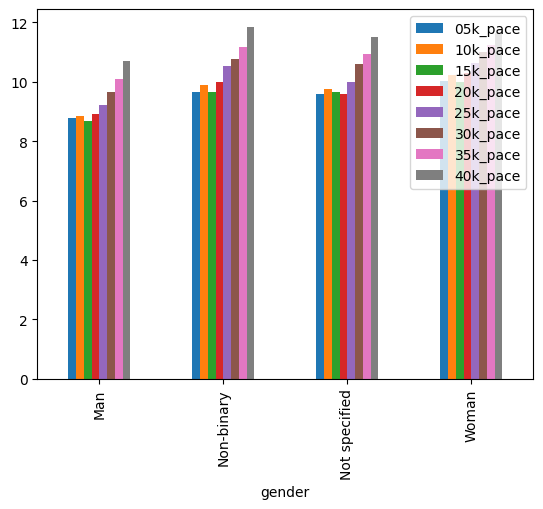

In [71]:
## Example 1: group by gender
# df_marathon['finish_hours'].hist(by=df_marathon['gender'], bins=200, ) 
grouped = df_marathon.groupby('gender')
print(grouped['finish_hours'].describe())

## mean finish time by group
grouped['finish_hours'].mean().plot(kind='bar')
plt.ylabel('finish_hours')
plt.show()

## histogram of finish time by group
grouped['finish_hours'].hist(bins=200, alpha=0.5 )
plt.title('finish time in hours')
plt.ylabel('count')
plt.show()

# plot of 5k paces by group
print(grouped[pace_columns].mean())
# grouped[pace_columns].mean().plot()
grouped[pace_columns].mean().plot(kind='bar')
plt.show()

Box plot of finish times by divisions

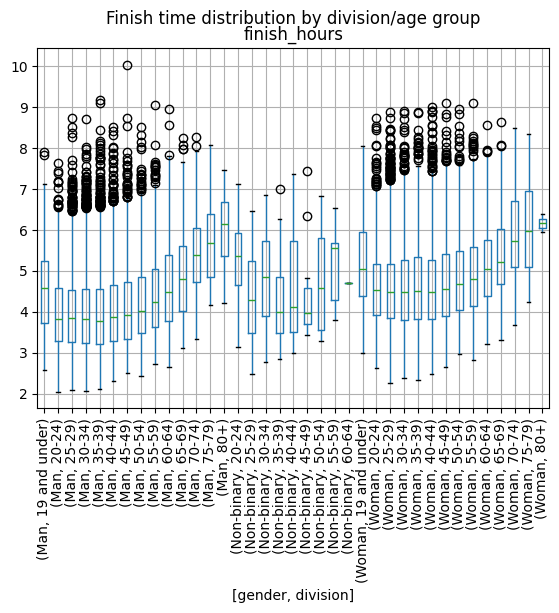

Text(0.5, 1.0, 'Average Finish Times')

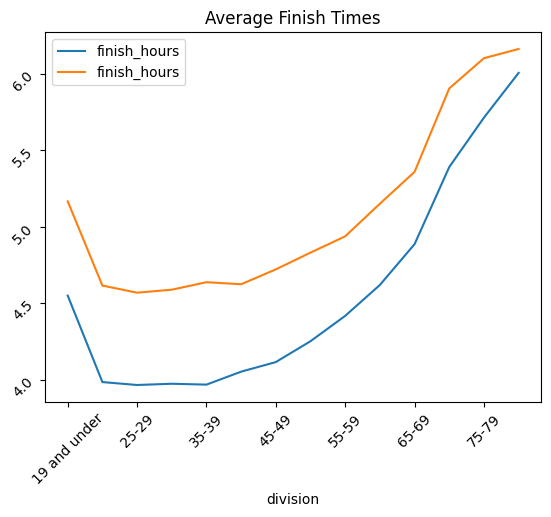

In [58]:

# SECOND EXAMPLE: boxplot by gender/age group
# df_groups_by_div_ag['finish_hours_mean'].boxplot()
df_marathon.boxplot(column=['finish_hours'],
               by=['gender','division'],
               rot=90)
plt.suptitle("Finish time distribution by division/age group")
plt.show()# print(df_marathon.columns)

## grouping by gender, division
grouped = df_marathon.groupby(['gender', 'division'])
# print(grouped['finish_hours'].describe())

## explore index of grouped data
# print(grouped['finish_hours'].mean().index)

## extract mean times for division by gender
# print(grouped['finish_hours'].mean().loc['Man'])
ax = grouped['finish_hours'].mean().loc['Man'].plot(legend=True)
ax = grouped['finish_hours'].mean().loc['Woman'].plot(legend=True)
ax.tick_params(axis='x', labelrotation=45) # Rotate by 45 degrees
ax.tick_params(axis='y', labelrotation=45) # Rotate by 45 degrees
plt.title('Average Finish Times')

Exploratory analysis: scatter plots

Basic: all runners

Text(0.5, 0, '05k_pace in minutes')

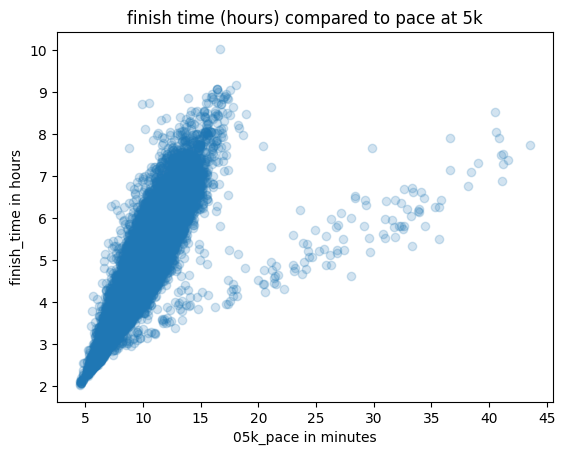

In [26]:
## basic scatter plot without coloring
plt.scatter(df_marathon['05k_pace'], df_marathon['finish_hours'], alpha=0.2)
plt.title('finish time (hours) compared to pace at 5k')
plt.ylabel('finish_time in hours')
plt.xlabel('05k_pace in minutes')



Another example: with color by gender

<StringArray>
['Man', 'Woman', 'Non-binary', 'Not specified']
Length: 4, dtype: str
{'Man': '#1f77b4', 'Woman': '#ff7f0e', 'Non-binary': '#2ca02c', 'Not specified': '#d62728'}


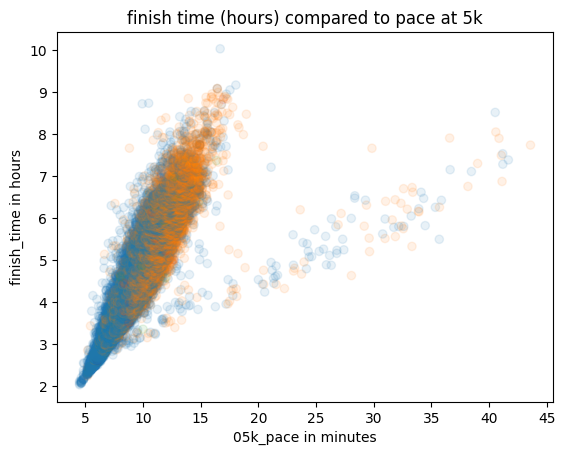

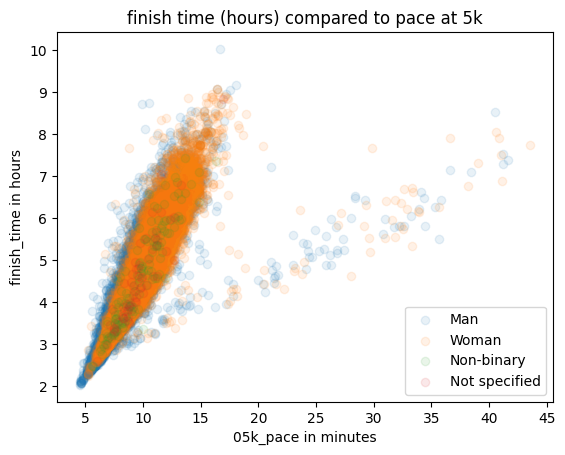

In [41]:

## add coloring by gender group
print(df_marathon["gender"].unique())
colors = dict(zip(df_marathon["gender"].unique(), 
                plt.rcParams['axes.prop_cycle'].by_key()["color"]))
print(colors)

# store colors to dataframe column
df_marathon["color"] = df_marathon["gender"].map(colors)
# print(df_marathon["color"].sample(10))

# scatter plot with grouping by color
_ = plt.scatter(df_marathon['05k_pace'], df_marathon['finish_hours'], 
                alpha=0.1, color=df_marathon["color"])
plt.title('finish time (hours) compared to pace at 5k')
plt.ylabel('finish_time in hours')
plt.xlabel('05k_pace in minutes')
plt.show()

# this legend doesn't work... maybe because only one column (Series) is being plotted?
# plt.legend(colors.keys(), loc='lower right')

# this works when we plot each gender one at a time:
for g in colors.keys():
    df_g = df_marathon.query(f"gender == '{g}'")
    plt.scatter(df_g['05k_pace'], df_g['finish_hours'], 
                alpha=0.1, color=colors[g])
plt.legend(colors.keys())
plt.title('finish time (hours) compared to pace at 5k')
plt.ylabel('finish_time in hours')
plt.xlabel('05k_pace in minutes')
plt.show()






{'20-24': '#1f77b4', '30-34': '#ff7f0e', '25-29': '#2ca02c', '35-39': '#d62728', '40-44': '#9467bd', '50-54': '#8c564b', '45-49': '#e377c2', '19 and under': '#7f7f7f', nan: '#bcbd22', '55-59': '#17becf'}


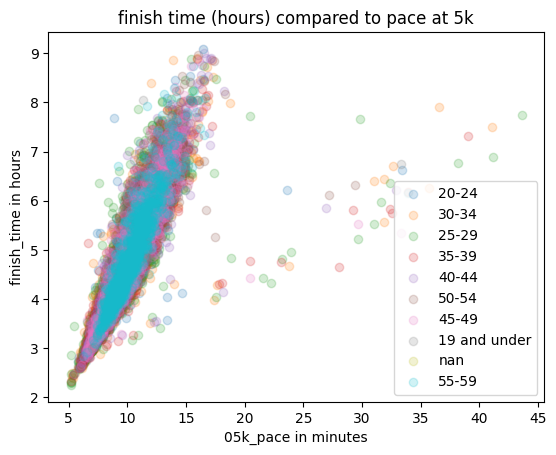

In [47]:

# ## second example with age division
# colors = dict(zip(df_marathon["gender"].unique(), 
#               plt.rcParams['axes.prop_cycle'].by_key()["color"]))
# print(colors)
# df_marathon["color"] = df_marathon["gender"].map(colors)
# # print(df_marathon["color"].sample(10))
# # df_marathon = df_marathon.query('gender == "Man" ').dropna()

# ## scatter plot with grouping by color
# plt.scatter(df_marathon['05k_pace'], df_marathon['finish_hours'], 
#             alpha=0.2, color=df_marathon["color"])
# plt.title('finish time (hours) compared to pace at 5k')
# plt.ylabel('finish_time in hours')
# plt.xlabel('05k_pace in minutes')
# plt.legend(labels=colors.keys())

## second example with age division
colors = dict(zip(df_marathon["division"].unique(), 
              plt.rcParams['axes.prop_cycle'].by_key()["color"]))
print(colors)
# select category: woman, then age division
df_tmp = df_marathon.query('gender == "Woman"')
df_tmp["color"] = df_tmp["division"].map(colors)

# this works when we plot each gender one at a time:
for div in colors.keys():
    df_div = df_tmp.query(f"division == '{div}'")
    plt.scatter(df_div['05k_pace'], df_div['finish_hours'], 
                alpha=0.2, color=colors[div])
plt.legend(colors.keys())
plt.title('finish time (hours) compared to pace at 5k')
plt.ylabel('finish_time in hours')
plt.xlabel('05k_pace in minutes')
plt.show()




Grouping data by gender, division

<Axes: xlabel='gender,division'>

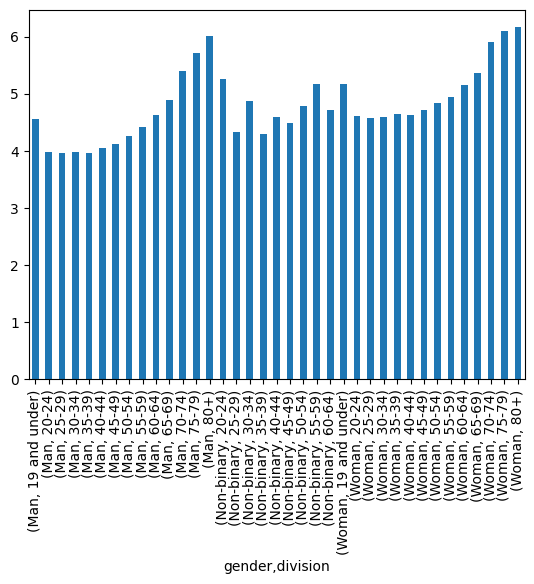

In [76]:

## grouping by gender, division
grouped = df_marathon.groupby(['gender', 'division'])

## find quantiles / explore BQ times??
df_groups_by_div_ag = pd.DataFrame(index=grouped['finish_hours'].mean().index)
df_groups_by_div_ag['counts'] = grouped['start_time'].count()

df_groups_by_div_ag['finish_hours_mean'] = grouped['finish_hours'].mean()
df_groups_by_div_ag['finish_hours_mean'].plot(kind='bar')






Create nicely-formatted time, show table

In [77]:
def format_hh_mm_ss(hours):
    '''Convert an a value in hours to HH:MM:SS formatting.'''
    h = int(hours)
    m = (hours - h) * 60
    s = (m - int(m)) * 60
    m = int(m)
    s = int(s)
    
    return f"{h:02}:{m:02}:{s:02}"

# create nicely-formatting time columns
df_groups_by_div_ag['finish_hours_mean'] = df_groups_by_div_ag['finish_hours_mean'].apply(format_hh_mm_ss)
df_groups_by_div_ag['90pct'] = grouped['finish_hours'].quantile(0.9).apply(format_hh_mm_ss)
df_groups_by_div_ag['75pct'] = grouped['finish_hours'].quantile(0.75).apply(format_hh_mm_ss)
df_groups_by_div_ag['50pct'] = grouped['finish_hours'].quantile(0.5).apply(format_hh_mm_ss)
df_groups_by_div_ag['25pct'] = grouped['finish_hours'].quantile(0.25).apply(format_hh_mm_ss)
df_groups_by_div_ag['10pct'] = grouped['finish_hours'].quantile(0.1).apply(format_hh_mm_ss)
# print(df_groups_by_div_ag.index)
mens_groups = [e for e in df_groups_by_div_ag.index if 'Man' in e]
print(df_groups_by_div_ag.loc[mens_groups])
womens_groups = [e for e in df_groups_by_div_ag.index if 'Woman' in e]
print(df_groups_by_div_ag.loc[womens_groups])


                     counts finish_hours_mean     90pct     75pct     50pct     25pct     10pct
gender division                                                                                
Man    19 and under     120          04:32:58  06:03:48  05:14:07  04:34:45  03:43:29  03:08:15
       20-24           1201          03:59:04  05:19:56  04:35:02  03:49:49  03:16:40  02:49:15
       25-29           4120          03:57:55  05:16:45  04:32:13  03:50:39  03:15:08  02:48:53
       30-34           4783          03:58:25  05:23:33  04:32:52  03:49:48  03:14:06  02:49:23
       35-39           4649          03:58:04  05:22:36  04:32:51  03:46:57  03:12:24  02:52:13
       40-44           4327          04:03:09  05:28:46  04:38:56  03:52:07  03:16:58  02:57:12
       45-49           3635          04:06:55  05:31:18  04:43:09  03:55:37  03:20:29  03:01:35
       50-54           2875          04:15:06  05:42:03  04:51:26  04:01:24  03:28:12  03:09:51
       55-59           1887          04:

Correlation and heatmap

              finish_hours  05k_pace  40k_pace  splits_std  start_place  finish_place  num_passed
finish_hours      1.000000  0.868958  0.926074    0.578183     0.802311      0.958441   -0.383022
05k_pace          0.868958  1.000000  0.719469    0.322736     0.746073      0.858664   -0.276848
40k_pace          0.926074  0.719469  1.000000    0.805221     0.702405      0.886449   -0.441975
splits_std        0.578183  0.322736  0.805221    1.000000     0.335769      0.533916   -0.485127
start_place       0.802311  0.746073  0.702405    0.335769     1.000000      0.916920    0.203814
finish_place      0.958441  0.858664  0.886449    0.533916     0.916920      1.000000   -0.203814
num_passed       -0.383022 -0.276848 -0.441975   -0.485127     0.203814     -0.203814    1.000000


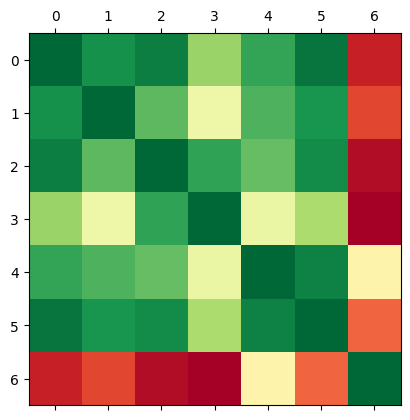

In [55]:

# correlation matrix of paces:
# c = df_marathon[pace_columns].corr()
c = df_marathon[['finish_hours', '05k_pace', '40k_pace','splits_std', 
                 'start_place', 'finish_place', 'num_passed']].corr()
print(c)

## default heatmap
_ = plt.matshow(c, cmap="RdYlGn")

## seaborn heatmap
# import seaborn
# plt.figure(figsize=(10, 8)) # Adjust figure size as needed
# ax = seaborn.heatmap(c, annot=True, cmap='coolwarm', fmt=".2f")
# ax.tick_params(axis='x', labelrotation=45) # Rotate by 45 degrees
# ax.tick_params(axis='y', labelrotation=45) # Rotate by 45 degrees
# plt.title('5k paces Correlation Heatmap')
# plt.show()




Query by criteria

In [85]:
print("total finishers: ", len(df_marathon))
df_result = df_marathon.query('finish_hours < 3')
print("under 3 hours:", len(df_result))



total finishers:  54269
under 3 hours: 4052
